In [13]:
import tensorflow as tf
import numpy as np, pandas as pd, cv2, time, base64, json, re
from pathlib import Path
import os
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from scipy.ndimage import uniform_filter1d
from groq import Groq

os.environ['TF_CUDNN_USE_AUTOTUNE']       = '0'
os.environ['TF_XLA_FLAGS']               = '--tf_xla_auto_jit=0'
os.environ['TF_DISABLE_MKL']             = '1'
os.environ['CUDA_DEVICE_MAX_CONNECTIONS']= '1'
tf.config.optimizer.set_jit(False)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f'GPU: {gpus[0].name}')

GROQ_API_KEY = ''
groq_client  = Groq(api_key=GROQ_API_KEY)
VLM_MODEL    = 'meta-llama/llama-4-scout-17b-16e-instruct'

DATA_ROOT = Path('/home/krish/vein_detection_task_3_training')
VIDEO_DIR = DATA_ROOT / 'Data/1-Videos'
OUT_DIR   = DATA_ROOT / 'output/classification'
PLOT_DIR  = OUT_DIR / 'plots'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 256
MEAN_NP  = np.array([0.485, 0.456, 0.406], np.float32)
STD_NP   = np.array([0.229, 0.224, 0.225], np.float32)
print('Setup done')

GPU: /physical_device:GPU:0
Setup done


In [14]:
fascia_model = tf.keras.models.load_model(
    str(DATA_ROOT / 'output/fascia/checkpoints/unet_resnet50_tf_best.keras'),
    compile=False)
vein_model = tf.keras.models.load_model(
    str(DATA_ROOT / 'output/vein/checkpoints/unet_resnet50_vein_best.keras'),
    compile=False)
lstm_model = tf.keras.models.load_model(
    str(DATA_ROOT / 'output/tracking/lstm_motion_predictor.keras'),
    compile=False)
print(f'Fascia: {fascia_model.output_shape}')
print(f'Vein  : {vein_model.output_shape}')

Fascia: (None, 384, 384, 3)
Vein  : (None, 256, 256, 2)


In [15]:
def preproces_old(bgr):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.
    return ((cv2.resize(rgb, (IMG_SIZE, IMG_SIZE)) - MEAN_NP) / STD_NP)[None]

def predict_fascia_mask_old(bgr):
    return np.argmax(fascia_model(preprocess(bgr), training=False).numpy()[0], -1).astype(np.uint8)

def predict_vein_mask_old(bgr):
    return np.argmax(vein_model(preprocess(bgr), training=False).numpy()[0], -1).astype(np.uint8)

def get_fascia_boundary(fascia_mask):
    fascia_bin = (fascia_mask == 1).astype(np.uint8)
    if fascia_bin.sum() < 50:
        return None, None
    top_y = np.full(IMG_SIZE, np.nan, dtype=np.float32)
    bot_y = np.full(IMG_SIZE, np.nan, dtype=np.float32)
    for x in range(IMG_SIZE):
        ys = np.where(fascia_bin[:, x] > 0)[0]
        if len(ys):
            top_y[x] = float(ys.min())
            bot_y[x] = float(ys.max())
    valid = ~np.isnan(top_y)
    if valid.sum() < 2:
        return None, None
    xs = np.arange(IMG_SIZE, dtype=np.float32)
    top_y = uniform_filter1d(np.interp(xs, xs[valid], top_y[valid]), size=15)
    bot_y = uniform_filter1d(np.interp(xs, xs[valid], bot_y[valid]), size=15)
    return top_y, bot_y

def preprocess(bgr, size=IMG_SIZE):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.
    return ((cv2.resize(rgb, (size, size)) - MEAN_NP) / STD_NP)[None]

FASCIA_SIZE = 384

def predict_fascia_mask(bgr):
    pred = fascia_model(preprocess(bgr, FASCIA_SIZE), training=False).numpy()[0]
    mask = np.argmax(pred, -1).astype(np.uint8)
    # resize back to IMG_SIZE so it's in the same coordinate space as vein mask
    return cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

def predict_vein_mask(bgr):
    pred = vein_model(preprocess(bgr, IMG_SIZE), training=False).numpy()[0]
    return np.argmax(pred, -1).astype(np.uint8)


def extract_detections(mask, min_area=50):
    n, _, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
    dets = []
    for i in range(1, n):
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area: continue
        dets.append({'bbox': (stats[i,cv2.CC_STAT_LEFT], stats[i,cv2.CC_STAT_TOP],
                               stats[i,cv2.CC_STAT_WIDTH], stats[i,cv2.CC_STAT_HEIGHT]),
                     'centroid': (float(centroids[i][0]), float(centroids[i][1])),
                     'area': int(area)})
    return dets

In [16]:
VLM_PROMPT = """You are analyzing an ultrasound image.

A CYAN line marks the fascia layer boundary. Numbered yellow boxes mark detected veins.

Classify each numbered vein based on its Y-position relative to the CYAN FASCIA LINE:
- N3 (Superficial vein): vein center is clearly ABOVE the fascia (top of image = skin surface)
- N2 (GSV): vein center is ON or VERY CLOSE to the fascia line
- N1 (Deep vein): vein center is clearly BELOW the fascia (bottom = deeper tissue)

Respond ONLY with a valid JSON object mapping each number to its label.
Example: {"1": "N2", "2": "N3", "3": "N1"}
No explanation, just the JSON."""


def annotate_frame_for_vlm(bgr, dets, top_y, bot_y):
    """Draw fascia boundary + numbered vein boxes. Returns annotated BGR."""
    vis = bgr.copy()
    h0, w0 = bgr.shape[:2]
    sx, sy = w0 / IMG_SIZE, h0 / IMG_SIZE

    if top_y is not None:
        pts = np.array([[int(x*sx), int(top_y[x]*sy)] for x in range(IMG_SIZE)], np.int32)
        cv2.polylines(vis, [pts], False, (0, 220, 220), 2)

    for idx, det in enumerate(dets, start=1):
        x, y, w, h = det['bbox']
        cx, cy = det['centroid']
        cv2.rectangle(vis, (int(x*sx), int(y*sy)),
                      (int((x+w)*sx), int((y+h)*sy)), (0, 255, 255), 2)
        cv2.putText(vis, str(idx), (int(x*sx), int(y*sy)-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

    return vis


def encode_bgr_to_b64(bgr):
    _, buf = cv2.imencode('.jpg', bgr, [cv2.IMWRITE_JPEG_QUALITY, 85])
    return base64.b64encode(buf.tobytes()).decode('utf-8')


def classify_with_vlm(bgr, dets, top_y, bot_y, retries=2):
    if not dets:
        return {}

    annotated = annotate_frame_for_vlm(bgr, dets, top_y, bot_y)
    b64 = encode_bgr_to_b64(annotated)

    for attempt in range(retries + 1):
        try:
            resp = groq_client.chat.completions.create(
                model=VLM_MODEL,
                messages=[{
                    'role': 'user',
                    'content': [
                        {'type': 'image_url',
                         'image_url': {'url': f'data:image/jpeg;base64,{b64}'}},
                        {'type': 'text', 'text': VLM_PROMPT}
                    ]
                }],
                max_tokens=200,
                temperature=0.0,
            )
            raw = resp.choices[0].message.content.strip()
            # Extract JSON even if model adds extra text
            match = re.search(r'\{[^}]+\}', raw)
            if match:
                parsed = json.loads(match.group())
                return {int(k): v for k, v in parsed.items()
                        if v in ('N1', 'N2', 'N3')}
        except Exception as e:
            if attempt < retries:
                time.sleep(1)
            else:
                print(f'  VLM error: {e}')
    return {}

In [17]:
def bbox_iou(b1, b2):
    x1,y1,w1,h1=b1; x2,y2,w2,h2=b2
    ix=max(0,min(x1+w1,x2+w2)-max(x1,x2))
    iy=max(0,min(y1+h1,y2+h2)-max(y1,y2))
    inter=ix*iy
    return inter/(w1*h1+w2*h2-inter+1e-6)

def match_detections(prev_dets, curr_dets, iou_threshold=0.2):
    if not prev_dets or not curr_dets:
        return [], list(range(len(curr_dets)))
    cost=np.array([[1.-bbox_iou(p['bbox'],c['bbox'])
                    for c in curr_dets] for p in prev_dets],dtype=np.float32)
    rows,cols=linear_sum_assignment(cost)
    matches,matched=[],set()
    for r,c in zip(rows,cols):
        if cost[r,c]<(1.-iou_threshold):
            matches.append((r,c)); matched.add(c)
    return matches,[j for j in range(len(curr_dets)) if j not in matched]

SEQ_LEN=5

class LSTMVeinTracker:
    def __init__(self,lstm_model,seq_len=SEQ_LEN,max_lost=5):
        self.lstm=lstm_model; self.seq_len=seq_len
        self.tracks={}; self.next_id=0; self.max_lost=max_lost

    def _predict_bboxes(self):
        tids,seqs=[],[]
        for tid,t in self.tracks.items():
            if len(t['history'])>=self.seq_len:
                tids.append(tid); seqs.append(t['history'][-self.seq_len:])
        predicted={}
        if seqs:
            preds=self.lstm(np.array(seqs,dtype=np.float32),training=False).numpy()
            for tid,p in zip(tids,preds):
                cx=float(np.clip(p[0],0,1))*IMG_SIZE; cy=float(np.clip(p[1],0,1))*IMG_SIZE
                w=float(np.clip(p[2],0.01,1))*IMG_SIZE; h=float(np.clip(p[3],0.01,1))*IMG_SIZE
                predicted[tid]=(int(cx-w/2),int(cy-h/2),int(w),int(h))
        return predicted

    def update(self,detections,frame_idx):
        predicted=self._predict_bboxes()
        active_ids=sorted(self.tracks.keys())
        prev_dets=[]
        for tid in active_ids:
            d=dict(self.tracks[tid]['last_det'])
            if tid in predicted: d['bbox']=predicted[tid]
            prev_dets.append(d)
        matches,unmatched=match_detections(prev_dets,detections)
        matched_prev={p for p,_ in matches}
        for p_idx,c_idx in matches:
            tid=active_ids[p_idx]; det=detections[c_idx]
            cx,cy=det['centroid']; x,y,w,h=det['bbox']
            self.tracks[tid].update({'last_det':det,'lost':0,'age':self.tracks[tid]['age']+1})
            self.tracks[tid]['history'].append([cx/IMG_SIZE,cy/IMG_SIZE,w/IMG_SIZE,h/IMG_SIZE])
        for i,tid in enumerate(active_ids):
            if i not in matched_prev: self.tracks[tid]['lost']+=1
        self.tracks={tid:t for tid,t in self.tracks.items() if t['lost']<=self.max_lost}
        for c_idx in unmatched:
            det=detections[c_idx]; cx,cy=det['centroid']; x,y,w,h=det['bbox']
            self.tracks[self.next_id]={'last_det':det,'lost':0,'age':1,
                'history':[[cx/IMG_SIZE,cy/IMG_SIZE,w/IMG_SIZE,h/IMG_SIZE]]}
            self.next_id+=1
        records=[]
        for tid,t in self.tracks.items():
            if t['lost']==0:
                det=t['last_det']; x,y,w,h=det['bbox']; cx,cy=det['centroid']
                records.append({'frame_idx':frame_idx,'track_id':tid,
                    'cx':round(cx,2),'cy':round(cy,2),
                    'x':x,'y':y,'w':w,'h':h,'area':det['area'],'age':t['age']})
        return records

In [18]:
LABEL_COLOR = {'N1':(255,80,50), 'N2':(50,255,100),
               'N3':(50,150,255), 'unknown':(180,180,180)}

def process_video_vlm(video_path, target_fps=5):
    cap     = cv2.VideoCapture(str(video_path))
    src_fps = cap.get(cv2.CAP_PROP_FPS) or 25
    skip    = max(1, round(src_fps / target_fps))
    tracker = LSTMVeinTracker(lstm_model)
    records = []
    raw_idx = 0; proc_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret: break

        if raw_idx % skip == 0:
            fascia_mask          = predict_fascia_mask(frame)
            vein_mask            = predict_vein_mask(frame)
            top_y, bot_y         = get_fascia_boundary(fascia_mask)
            dets                 = extract_detections(vein_mask)
            track_records        = tracker.update(dets, proc_idx)

            # VLM classification — one call per frame that has detections
            vlm_labels = {}
            if dets:
                vlm_labels = classify_with_vlm(frame, dets, top_y, bot_y)

            for i, r in enumerate(track_records, start=1):
                r['label']         = vlm_labels.get(i, 'unknown')
                r['video']         = video_path.stem
                r['raw_frame_idx'] = raw_idx
                records.append(r)

            n_det = len(dets)
            if n_det:
                labels = list(vlm_labels.values())
                print(f'  frame {proc_idx:4d} | {n_det} veins | {labels}')

            proc_idx += 1
        raw_idx += 1

    cap.release()
    return pd.DataFrame(records), proc_idx


videos = sorted({p for ext in ['*.mp4','*.MP4','*.avi','*.AVI']
                 for p in VIDEO_DIR.glob(ext)})

all_dfs = []
for vp in sorted(videos):
    print(f'\n=== {vp.name} ===')
    t0 = time.time()
    df, n_frames = process_video_vlm(vp)
    elapsed = time.time() - t0
    if len(df):
        counts = df.groupby('label')['track_id'].nunique().to_dict()
    else:
        counts = {}
    all_dfs.append(df)
    print(f'Done: {n_frames}f | N1={counts.get("N1",0)} N2={counts.get("N2",0)} N3={counts.get("N3",0)} | {elapsed:.1f}s')

classified_df = pd.concat(all_dfs, ignore_index=True) if all_dfs else pd.DataFrame()
classified_df.to_csv(OUT_DIR / 'vein_classified_vlm.csv', index=False)
print(f'\nTotal records saved: {len(classified_df)}')


=== 202207111318_38-Perf.mp4 ===
  frame    0 | 2 veins | ['N1', 'N3']
  frame    1 | 1 veins | ['N3']
  frame    2 | 2 veins | ['N3', 'N3']
  frame    3 | 3 veins | ['N3', 'N2', 'N1']
  frame    4 | 1 veins | ['N3']
  frame    5 | 2 veins | ['N3', 'N1']
  frame    6 | 1 veins | ['N3']
  frame    7 | 2 veins | ['N3', 'N2']


W0000 00:00:1779948251.365466   29812 gpu_kernel_to_blob_pass.cc:190] Failed to compile generated PTX with ptxas. Falling back to compilation by driver.


  frame    8 | 2 veins | ['N3', 'N3']
  frame    9 | 2 veins | ['N3', 'N2']
  frame   10 | 2 veins | []
  frame   11 | 1 veins | ['N3']
  frame   12 | 1 veins | ['N3']
  frame   13 | 1 veins | ['N3']
  frame   14 | 1 veins | ['N3']
  frame   15 | 1 veins | ['N3']
  frame   16 | 1 veins | ['N3']
  frame   17 | 1 veins | ['N3']
  frame   21 | 2 veins | []
  frame   22 | 2 veins | ['N3', 'N2']
  frame   23 | 2 veins | ['N3', 'N2']
  frame   24 | 1 veins | ['N3']
  frame   25 | 1 veins | ['N2']
  frame   26 | 3 veins | ['N1', 'N2', 'N3']
  frame   27 | 2 veins | ['N3', 'N2']
  frame   28 | 2 veins | ['N3', 'N2']
  frame   29 | 2 veins | ['N3']
  frame   30 | 2 veins | ['N3', 'N2']
  frame   31 | 2 veins | ['N3', 'N2']
  frame   32 | 2 veins | ['N3', 'N2']
  frame   33 | 2 veins | ['N3', 'N2']
  frame   34 | 2 veins | ['N1', 'N2']
  frame   35 | 3 veins | ['N3', 'N2', 'N3']
  frame   36 | 2 veins | []
  frame   37 | 2 veins | ['N2', 'N3']
  frame   38 | 2 veins | ['N3', 'N2']
  frame   39 |

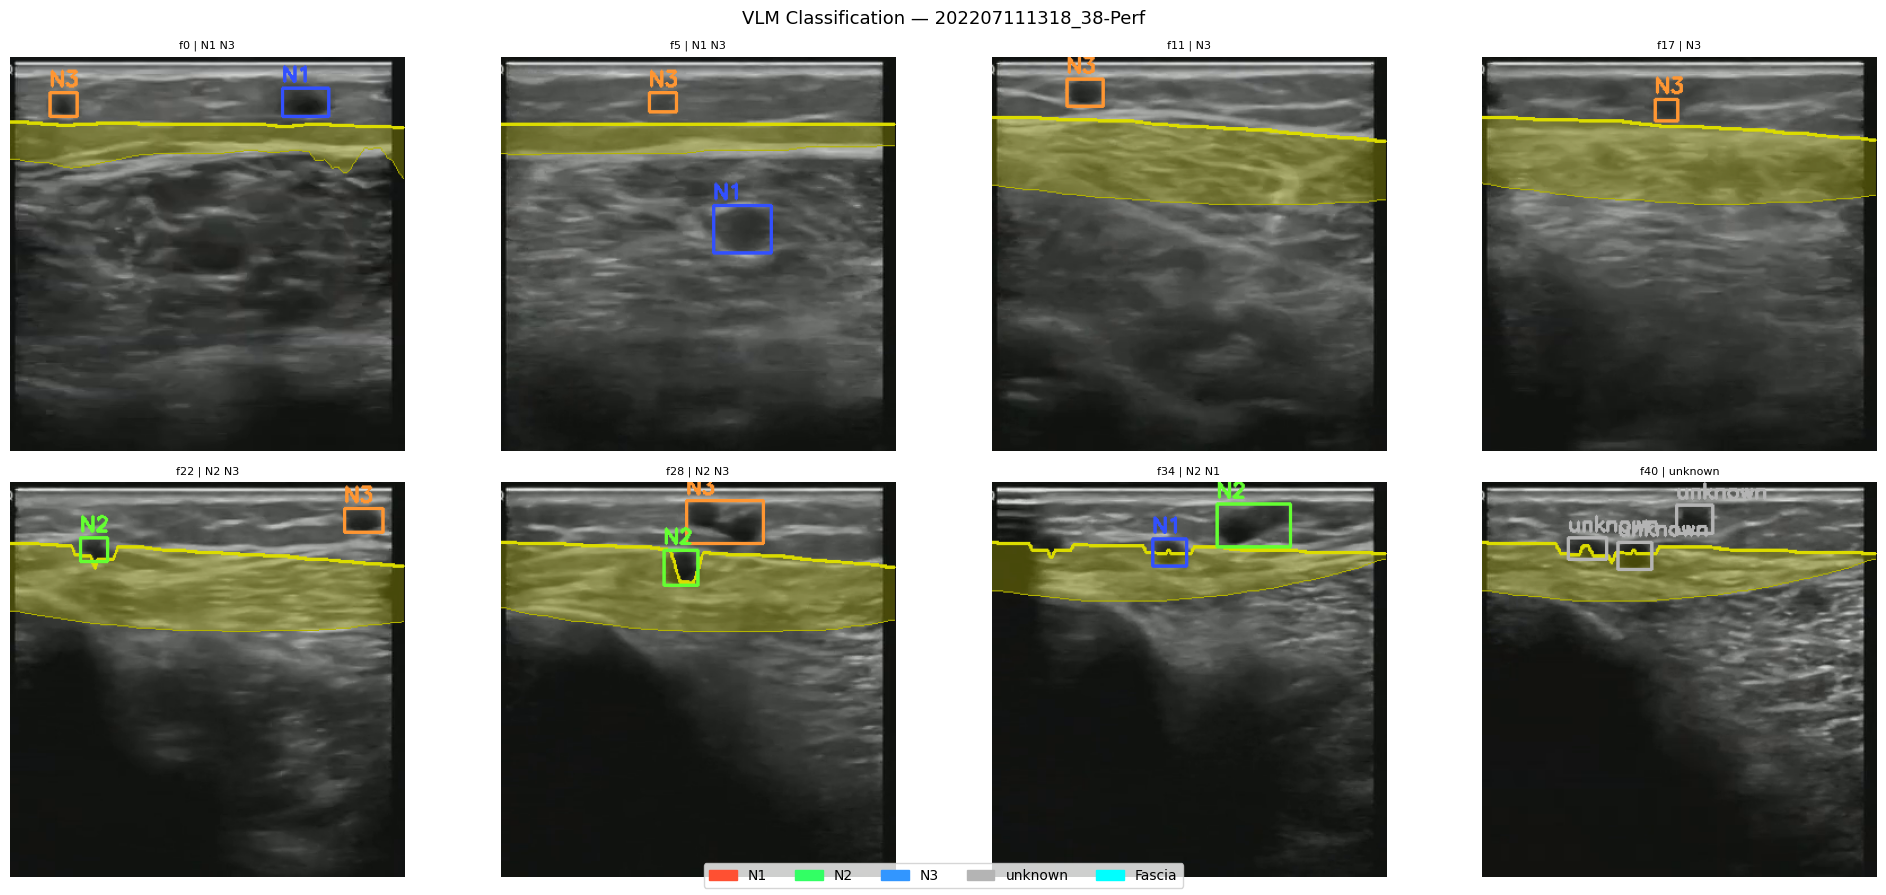

In [21]:
def draw_classified_old(bgr, records, top_y, bot_y):
    vis = bgr.copy()
    h0, w0 = bgr.shape[:2]
    sx, sy = w0/IMG_SIZE, h0/IMG_SIZE
    if top_y is not None:
        pts = np.array([[int(x*sx),int(top_y[x]*sy)] for x in range(IMG_SIZE)],np.int32)
        cv2.polylines(vis,[pts],False,(0,220,220),2)
    for r in records:
        col=LABEL_COLOR.get(r['label'],(180,180,180))
        x,y=int(r['x']*sx),int(r['y']*sy)
        w,h=int(r['w']*sx),int(r['h']*sy)
        cv2.rectangle(vis,(x,y),(x+w,y+h),col,2)
        cv2.putText(vis,r['label'],(x,y-6),cv2.FONT_HERSHEY_SIMPLEX,0.6,col,2)
    return vis

sample_vp = next((vp for vp in sorted(videos)
                  if len(classified_df[classified_df['video']==vp.stem])>0),None)

def draw_classified(bgr, records, top_y, bot_y):
    vis = bgr.copy()
    h0, w0 = bgr.shape[:2]
    sx, sy = w0/IMG_SIZE, h0/IMG_SIZE

    if top_y is not None:
        # Fill fascia band with semi-transparent yellow
        overlay = vis.copy()
        pts_top = np.array([[int(x*sx), int(top_y[x]*sy)] for x in range(IMG_SIZE)], np.int32)
        pts_bot = np.array([[int(x*sx), int(bot_y[x]*sy)] for x in range(IMG_SIZE)], np.int32)
        band = np.vstack([pts_top, pts_bot[::-1]])
        cv2.fillPoly(overlay, [band], (0, 200, 200))
        cv2.addWeighted(overlay, 0.3, vis, 0.7, 0, vis)
        # Draw top and bottom edges
        cv2.polylines(vis, [pts_top], False, (0, 220, 220), 2)
        cv2.polylines(vis, [pts_bot], False, (0, 180, 180), 1)

    for r in records:
        col = LABEL_COLOR.get(r['label'], (180,180,180))
        x,y = int(r['x']*sx), int(r['y']*sy)
        w,h = int(r['w']*sx), int(r['h']*sy)
        cv2.rectangle(vis, (x,y), (x+w,y+h), col, 2)
        cv2.putText(vis, r['label'], (x, y-6),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, col, 2)
    return vis


if sample_vp:
    cap  = cv2.VideoCapture(str(sample_vp))
    df_v = classified_df[classified_df['video']==sample_vp.stem]
    fis  = np.linspace(0, int(df_v['frame_idx'].max()), 8, dtype=int)
    fig, axes = plt.subplots(2,4,figsize=(20,9))
    for ax,fi in zip(axes.flat,fis):
        rows=df_v[df_v['frame_idx']==fi]
        raw_fi=int(rows['raw_frame_idx'].iloc[0]) if len(rows) else fi*round(src_fps/5)
        cap.set(cv2.CAP_PROP_POS_FRAMES,raw_fi)
        ret,frame=cap.read()
        if not ret: ax.axis('off'); continue
        fascia_mask=predict_fascia_mask(frame)
        top_y,bot_y=get_fascia_boundary(fascia_mask)
        vis=draw_classified(frame,rows.to_dict('records'),top_y,bot_y)
        ax.imshow(cv2.cvtColor(vis,cv2.COLOR_BGR2RGB))
        lbl=' '.join(set(r['label'] for r in rows.to_dict('records'))) if len(rows) else '-'
        ax.set_title(f'f{fi} | {lbl}',fontsize=8); ax.axis('off')
    cap.release()
    from matplotlib.patches import Patch
    legend=[Patch(color=np.array(c)/255,label=f'{k}') for k,c in LABEL_COLOR.items()]
    legend.append(Patch(color='cyan',label='Fascia'))
    fig.legend(handles=legend,loc='lower center',ncol=5,fontsize=10)
    plt.suptitle(f'VLM Classification — {sample_vp.stem}',fontsize=13)
    plt.tight_layout()
    plt.savefig(str(PLOT_DIR/'vlm_classification.png'),dpi=130,bbox_inches='tight')
    plt.show()

  VLM VEIN CLASSIFICATION — SUMMARY

  202207111318_38-Perf
    N1: 5 tracks
    N2: 14 tracks
    N3: 20 tracks
    unknown: 7 tracks

  202207191643_00-Moving
    N1: 13 tracks
    N2: 9 tracks
    N3: 17 tracks
    unknown: 2 tracks

  Knee-Ankle-Seg1
    N2: 1 tracks
    N3: 8 tracks
    unknown: 5 tracks

  sample_data
    N1: 11 tracks
    N2: 18 tracks
    N3: 20 tracks
    unknown: 11 tracks

  OVERALL
    N1: 20 tracks
    N2: 26 tracks
    N3: 33 tracks
    unknown: 20 tracks


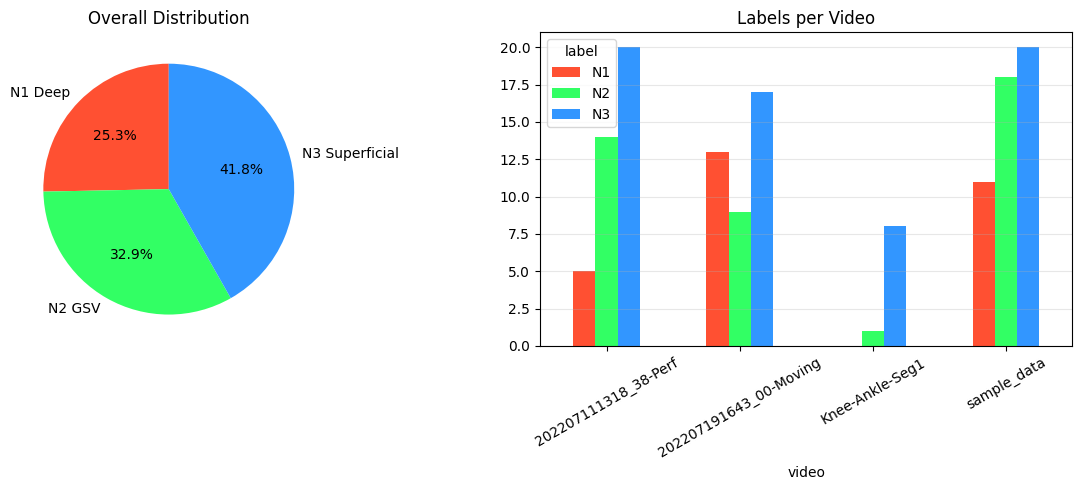

In [22]:
print('='*50)
print('  VLM VEIN CLASSIFICATION — SUMMARY')
print('='*50)
for video, grp in classified_df.groupby('video'):
    counts = grp.groupby('label')['track_id'].nunique()
    print(f'\n  {video}')
    for lbl in ['N1','N2','N3','unknown']:
        n = counts.get(lbl,0)
        if n: print(f'    {lbl}: {n} tracks')

overall = classified_df.groupby('label')['track_id'].nunique()
print('\n  OVERALL')
for lbl in ['N1','N2','N3','unknown']:
    print(f'    {lbl}: {overall.get(lbl,0)} tracks')

fig, axes = plt.subplots(1,2,figsize=(12,5))
sizes  = [overall.get(k,0) for k in ['N1','N2','N3']]
colors = [np.array(LABEL_COLOR[k])/255 for k in ['N1','N2','N3']]
axes[0].pie(sizes,labels=['N1 Deep','N2 GSV','N3 Superficial'],
            colors=colors,autopct='%1.1f%%',startangle=90)
axes[0].set_title('Overall Distribution')
pv=classified_df.groupby(['video','label'])['track_id'].nunique().unstack(fill_value=0)
pv[['N1','N2','N3']].plot(kind='bar',ax=axes[1],
    color=[np.array(LABEL_COLOR[k])/255 for k in ['N1','N2','N3']])
axes[1].set_title('Labels per Video'); axes[1].tick_params(axis='x',rotation=30)
axes[1].grid(True,alpha=0.3,axis='y')
plt.tight_layout()
plt.savefig(str(PLOT_DIR/'vlm_summary.png'),dpi=130,bbox_inches='tight')
plt.show()
print('='*50)

In [23]:
! cp -r /home/krish/vein_detection_task_3_training /mnt/c/Users/Krish/Downloads/Task_3/